In [1]:
# Imports et configuration générale

from pathlib import Path
from collections import Counter
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_ROOT = PROJECT_DIR / "data"
ALL_IMAGES_DIR = DATA_ROOT / "all_images"

# Choix possible : "all_images" ou "class_directories"
DATA_LAYOUT = "class_directories"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version      :", tf.__version__)
print("Data root exists        :", DATA_ROOT.exists())
print("All images dir exists   :", ALL_IMAGES_DIR.exists())
print("Selected data layout    :", DATA_LAYOUT)
print("GPU available           :", tf.config.list_physical_devices("GPU"))


I0000 00:00:1773865243.420550  245612 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773865243.796280  245612 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773865245.476544  245612 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version      : 2.21.0
Data root exists        : True
All images dir exists   : True
Selected data layout    : class_directories
GPU available           : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Construire un DataFrame selon l'architecture de données choisie

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
EXCLUDED_CLASS_DIRS = {"all_images", "__pycache__"}


def extract_label_from_filename(filename: str) -> str:
    match = re.match(r"(.+)_\d+\.[^.]+$", filename)
    if not match:
        raise ValueError(f"Nom de fichier inattendu : {filename}")
    return match.group(1)


def build_df_from_all_images(all_images_dir: Path) -> pd.DataFrame:
    image_paths = sorted(
        [p for p in all_images_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
    )

    df_local = pd.DataFrame({
        "filepath": [str(p) for p in image_paths],
        "filename": [p.name for p in image_paths],
    })
    df_local["label"] = df_local["filename"].apply(extract_label_from_filename)
    df_local["data_layout"] = "all_images"
    return df_local


def build_df_from_class_directories(data_root: Path) -> pd.DataFrame:
    records = []

    class_dirs = sorted(
        [
            d for d in data_root.iterdir()
            if d.is_dir() and d.name not in EXCLUDED_CLASS_DIRS
        ]
    )

    for class_dir in class_dirs:
        for image_path in sorted(class_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "filepath": str(image_path),
                    "filename": image_path.name,
                    "label": class_dir.name,
                    "data_layout": "class_directories",
                })

    return pd.DataFrame(records)


if DATA_LAYOUT == "all_images":
    df = build_df_from_all_images(ALL_IMAGES_DIR)
    DATA_SOURCE_PATH = ALL_IMAGES_DIR
elif DATA_LAYOUT == "class_directories":
    df = build_df_from_class_directories(DATA_ROOT)
    DATA_SOURCE_PATH = DATA_ROOT
else:
    raise ValueError(
        "DATA_LAYOUT doit valoir 'all_images' ou 'class_directories'"
    )

if df.empty:
    raise ValueError(f"Aucune image trouvée pour DATA_LAYOUT={DATA_LAYOUT}")

print(f"Source sélectionnée     : {DATA_SOURCE_PATH}")
print(f"Nombre total d'images   : {len(df)}")
print(f"Nombre de classes       : {df['label'].nunique()}")
display(df.head())


Source sélectionnée     : /home/thomashebert99/code/thomashebert99/plant_detect/data
Nombre total d'images   : 12713
Nombre de classes       : 26


,filepath,filename,label,data_layout
0,/home/thomashebert99/code/thomashebert99/plant...,0.jpg,angelica,class_directories
1,/home/thomashebert99/code/thomashebert99/plant...,1.jpg,angelica,class_directories
2,/home/thomashebert99/code/thomashebert99/plant...,10.jpg,angelica,class_directories
3,/home/thomashebert99/code/thomashebert99/plant...,100.jpg,angelica,class_directories
4,/home/thomashebert99/code/thomashebert99/plant...,101.jpg,angelica,class_directories


label
angelica         499
basil            500
bay_leaf         500
borage           500
chamomile        500
chives           500
coriander        500
dill             500
fennel           500
holy_basil       500
hyssop           500
lavender         500
lemon_balm       500
lemon_verbena    500
lemongrass       501
lovage           394
mint             500
mugwort          500
oregano          500
parsley          500
rosemary         500
sage             500
savory           317
tarragon         500
thyme            502
wintergreen      500
Name: count, dtype: int64

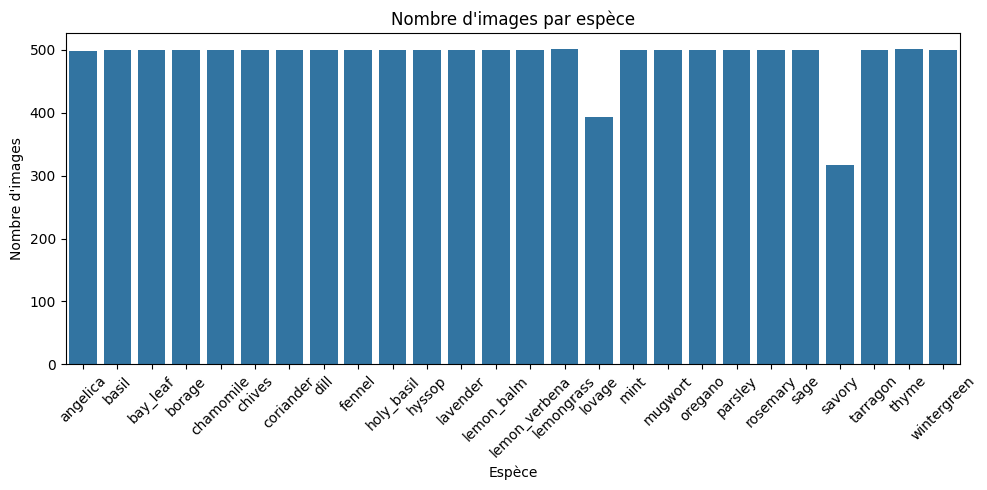

In [3]:
# Vérification de la distribution des classes

class_counts = df["label"].value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Nombre d'images par espèce")
plt.xlabel("Espèce")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
# Définir les modèles candidats du benchmark TensorFlow

TF_MODELS = {
    "MobileNetV2": {
        "builder": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "input_size": (224, 224),
    },
    "EfficientNetB0": {
        "builder": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "input_size": (224, 224),
    },
    "ResNet50": {
        "builder": tf.keras.applications.ResNet50,
        "preprocess": tf.keras.applications.resnet50.preprocess_input,
        "input_size": (224, 224),
    },
}

NUM_CLASSES = df["label"].nunique()
CLASS_NAMES = sorted(df["label"].unique())

print("Classes :", CLASS_NAMES)
print("Nombre de classes :", NUM_CLASSES)
print("Modèles testés :", list(TF_MODELS.keys()))


Classes : ['angelica', 'basil', 'bay_leaf', 'borage', 'chamomile', 'chives', 'coriander', 'dill', 'fennel', 'holy_basil', 'hyssop', 'lavender', 'lemon_balm', 'lemon_verbena', 'lemongrass', 'lovage', 'mint', 'mugwort', 'oregano', 'parsley', 'rosemary', 'sage', 'savory', 'tarragon', 'thyme', 'wintergreen']
Nombre de classes : 26
Modèles testés : ['MobileNetV2', 'EfficientNetB0', 'ResNet50']


In [5]:
# Conclusion de l'étape 1

print("Etape 1 OK")
print(f"- Layout sélectionné : {DATA_LAYOUT}")
print(f"- Source            : {DATA_SOURCE_PATH}")
print(f"- Dataset détecté   : {len(df)} images")
print(f"- Classes           : {NUM_CLASSES}")
print(f"- Modèles TF        : {list(TF_MODELS.keys())}")


Etape 1 OK
- Layout sélectionné : class_directories
- Source            : /home/thomashebert99/code/thomashebert99/plant_detect/data
- Dataset détecté   : 12713 images
- Classes           : 26
- Modèles TF        : ['MobileNetV2', 'EfficientNetB0', 'ResNet50']


In [6]:
# Split train / validation / test stratifié

from sklearn.model_selection import train_test_split

TEST_SIZE = 0.15
VAL_SIZE = 0.15
RANDOM_STATE = SEED

df_train_val, df_test = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

val_relative_size = VAL_SIZE / (1 - TEST_SIZE)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=val_relative_size,
    stratify=df_train_val["label"],
    random_state=RANDOM_STATE,
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Train size :", len(df_train))
print("Val size   :", len(df_val))
print("Test size  :", len(df_test))


Train size : 8899
Val size   : 1907
Test size  : 1907


,train,val,test
label,,,
angelica,0.039218,0.039329,0.039329
basil,0.039330,0.039329,0.039329
bay_leaf,0.039330,0.039329,0.039329
borage,0.039330,0.039329,0.039329
chamomile,0.039330,0.039329,0.039329
chives,0.039330,0.039329,0.039329
coriander,0.039330,0.039329,0.039329
dill,0.039330,0.039329,0.039329
fennel,0.039330,0.039329,0.039329


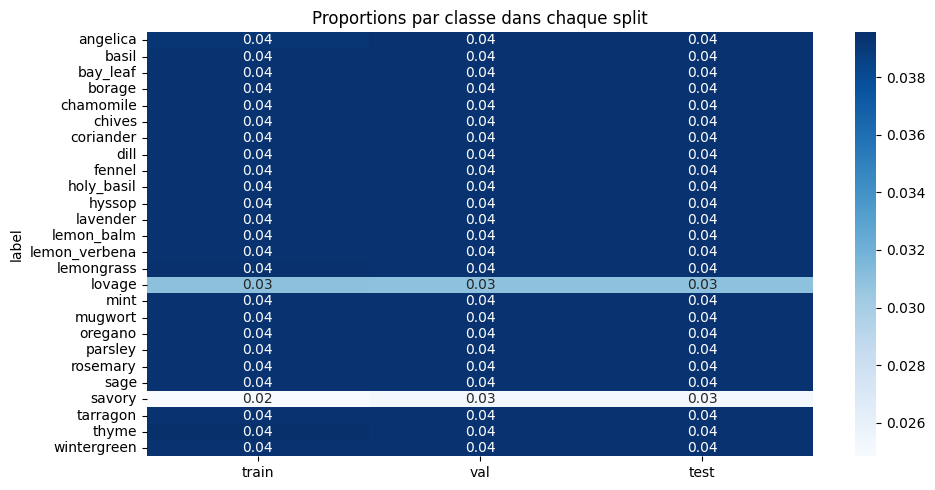

In [7]:
# Vérifier que la stratification est correcte

split_summary = pd.DataFrame({
    "train": df_train["label"].value_counts(normalize=True),
    "val": df_val["label"].value_counts(normalize=True),
    "test": df_test["label"].value_counts(normalize=True),
}).fillna(0)

display(split_summary)

plt.figure(figsize=(10, 5))
sns.heatmap(split_summary, annot=True, cmap="Blues", fmt=".2f")
plt.title("Proportions par classe dans chaque split")
plt.tight_layout()
plt.show()


In [8]:
# Encodage des labels

label_to_index = {label: idx for idx, label in enumerate(CLASS_NAMES)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

df_train["label_id"] = df_train["label"].map(label_to_index)
df_val["label_id"] = df_val["label"].map(label_to_index)
df_test["label_id"] = df_test["label"].map(label_to_index)

display(df_train.head())
print(label_to_index)


,filepath,filename,label,data_layout,label_id
0,/home/thomashebert99/code/thomashebert99/plant...,261.jpg,tarragon,class_directories,23
1,/home/thomashebert99/code/thomashebert99/plant...,483.jpg,mint,class_directories,16
2,/home/thomashebert99/code/thomashebert99/plant...,108.jpg,sage,class_directories,21
3,/home/thomashebert99/code/thomashebert99/plant...,216.jpg,holy_basil,class_directories,9
4,/home/thomashebert99/code/thomashebert99/plant...,1.jpg,lemon_verbena,class_directories,13


{'angelica': 0, 'basil': 1, 'bay_leaf': 2, 'borage': 3, 'chamomile': 4, 'chives': 5, 'coriander': 6, 'dill': 7, 'fennel': 8, 'holy_basil': 9, 'hyssop': 10, 'lavender': 11, 'lemon_balm': 12, 'lemon_verbena': 13, 'lemongrass': 14, 'lovage': 15, 'mint': 16, 'mugwort': 17, 'oregano': 18, 'parsley': 19, 'rosemary': 20, 'sage': 21, 'savory': 22, 'tarragon': 23, 'thyme': 24, 'wintergreen': 25}


In [9]:
# Fonction de lecture / preprocessing d'une image

def load_and_resize_image(filepath, label, image_size=(224, 224), preprocess_fn=None):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32)

    if preprocess_fn is not None:
        image = preprocess_fn(image)

    return image, label


In [10]:
# Fonction générique pour construire un tf.data.Dataset

def make_tf_dataset(
    dataframe,
    image_size=(224, 224),
    batch_size=32,
    preprocess_fn=None,
    shuffle=False,
):
    filepaths = dataframe["filepath"].astype(str).to_list()
    labels = dataframe["label_id"].astype("int32").to_list()

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    ds = ds.map(
        lambda x, y: load_and_resize_image(
            x,
            y,
            image_size=image_size,
            preprocess_fn=preprocess_fn,
        ),
        num_parallel_calls=AUTOTUNE,
    )

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


In [11]:
# Exemple: créer les datasets pour un modèle donné

MODEL_NAME = "EfficientNetB0"

model_config = TF_MODELS[MODEL_NAME]
image_size = model_config["input_size"]
preprocess_fn = model_config["preprocess"]

train_ds = make_tf_dataset(
    df_train,
    image_size=image_size,
    batch_size=BATCH_SIZE,
    preprocess_fn=preprocess_fn,
    shuffle=True,
)

val_ds = make_tf_dataset(
    df_val,
    image_size=image_size,
    batch_size=BATCH_SIZE,
    preprocess_fn=preprocess_fn,
    shuffle=False,
)

test_ds = make_tf_dataset(
    df_test,
    image_size=image_size,
    batch_size=BATCH_SIZE,
    preprocess_fn=preprocess_fn,
    shuffle=False,
)

print(train_ds)
print(val_ds)
print(test_ds)


I0000 00:00:1773865247.048487  245612 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


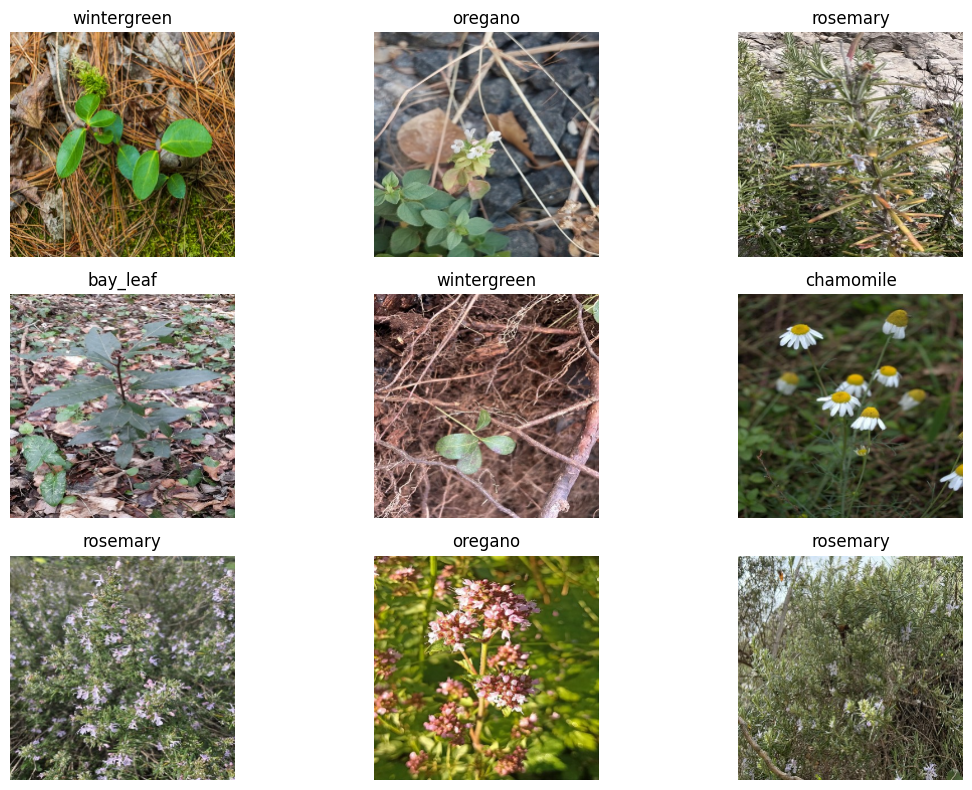

In [12]:
# Vérification visuelle rapide d'un batch

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)

    img = images[i].numpy()

    # Affichage plus lisible si preprocess_input a changé l'échelle
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img_to_show = (img - img_min) / (img_max - img_min)
    else:
        img_to_show = img

    plt.imshow(img_to_show)
    plt.title(index_to_label[int(labels[i].numpy())])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [13]:
# Hyperparamètres d'entraînement

from sklearn.utils.class_weight import compute_class_weight

EPOCHS_HEAD = 12
LEARNING_RATE_HEAD = 1e-3
DROPOUT_RATE = 0.30

# Recommandation pratique :
# - all_images : True, car le dataset est souvent plus déséquilibré
# - class_directories : False, car le dataset est en général beaucoup plus équilibré
USE_CLASS_WEIGHTS = DATA_LAYOUT == "all_images"

MODEL_SAVE_DIR = PROJECT_DIR / "notebooks" / "models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

def build_class_weights(dataframe):
    classes = np.array(sorted(dataframe["label_id"].unique()))
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=dataframe["label_id"].values,
    )
    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}

CLASS_WEIGHTS = build_class_weights(df_train) if USE_CLASS_WEIGHTS else None

print("USE_CLASS_WEIGHTS :", USE_CLASS_WEIGHTS)
if CLASS_WEIGHTS is not None:
    display(pd.Series(CLASS_WEIGHTS, name="class_weight").sort_index())


USE_CLASS_WEIGHTS : False


In [14]:
# Data augmentation TensorFlow

def make_data_augmentation():
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.08),
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomContrast(0.10),
        ],
        name="data_augmentation",
    )


In [15]:
# Fonction de construction du modèle

def build_transfer_model(
    model_name,
    num_classes,
    input_shape=(224, 224, 3),
    dropout_rate=0.30,
    train_base=False,
):
    config = TF_MODELS[model_name]
    base_builder = config["builder"]

    base_model = base_builder(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )
    base_model.trainable = train_base

    data_augmentation = make_data_augmentation()

    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name="classifier",
    )(x)

    model = tf.keras.Model(inputs, outputs, name=f"{model_name}_transfer")
    return model, base_model


In [16]:
# Fonction de compilation

def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        ],
    )
    return model


In [17]:
# Callbacks d'entraînement

def make_callbacks(model_name):
    checkpoint_path = MODEL_SAVE_DIR / f"{model_name}_head_only_best.keras"

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    return callbacks, checkpoint_path


In [18]:
# Fonction d'entraînement générique pour un backbone

def train_head_only_model(
    model_name,
    df_train,
    df_val,
    num_classes,
    batch_size=32,
    epochs=12,
    learning_rate=1e-3,
    dropout_rate=0.30,
    use_class_weights=USE_CLASS_WEIGHTS,
):
    config = TF_MODELS[model_name]
    image_size = config["input_size"]
    preprocess_fn = config["preprocess"]

    train_ds = make_tf_dataset(
        df_train,
        image_size=image_size,
        batch_size=batch_size,
        preprocess_fn=preprocess_fn,
        shuffle=True,
    )

    val_ds = make_tf_dataset(
        df_val,
        image_size=image_size,
        batch_size=batch_size,
        preprocess_fn=preprocess_fn,
        shuffle=False,
    )

    model, base_model = build_transfer_model(
        model_name=model_name,
        num_classes=num_classes,
        input_shape=(*image_size, 3),
        dropout_rate=dropout_rate,
        train_base=False,
    )

    model = compile_model(model, learning_rate=learning_rate)
    callbacks, checkpoint_path = make_callbacks(model_name)
    class_weights = build_class_weights(df_train) if use_class_weights else None

    print(f"Class weights actifs pour {model_name} : {use_class_weights}")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
        class_weight=class_weights,
    )

    return {
        "model_name": model_name,
        "model": model,
        "base_model": base_model,
        "history": history,
        "train_ds": train_ds,
        "val_ds": val_ds,
        "checkpoint_path": checkpoint_path,
        "class_weights": class_weights,
        "use_class_weights": use_class_weights,
    }


In [19]:
# Lancer un premier entraînement sur un seul modèle

MODEL_NAME = "EfficientNetB0"

run = train_head_only_model(
    model_name=MODEL_NAME,
    df_train=df_train,
    df_val=df_val,
    num_classes=NUM_CLASSES,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_HEAD,
    learning_rate=LEARNING_RATE_HEAD,
    dropout_rate=DROPOUT_RATE,
)


Class weights actifs pour EfficientNetB0 : False
Epoch 1/12


I0000 00:00:1773865256.287854  245749 cuda_dnn.cc:461] Loaded cuDNN version 91002


279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2328 - loss: 2.7586
Epoch 1: val_accuracy improved from None to 0.49921, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.3276 - loss: 2.4131 - val_accuracy: 0.4992 - val_loss: 1.7661 - learning_rate: 0.0010
Epoch 2/12
277/279 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4650 - loss: 1.8844
Epoch 2: val_accuracy improved from 0.49921 to 0.55165, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0

In [20]:
# Résumé du modèle

run["model"].summary()


Model: "EfficientNetB0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 26)             │        33,306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,149,491 (15.83 MB)

 Trainable params: 33,306 (130.10 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 66,614 (260.21 KB)

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.327565,2.413132,0.499213,1.766127,0.001
1,0.476233,1.842288,0.551652,1.543543,0.001
2,0.523767,1.665859,0.574725,1.452097,0.001
3,0.541634,1.569447,0.594127,1.375902,0.001
4,0.555905,1.505531,0.610383,1.335194,0.001


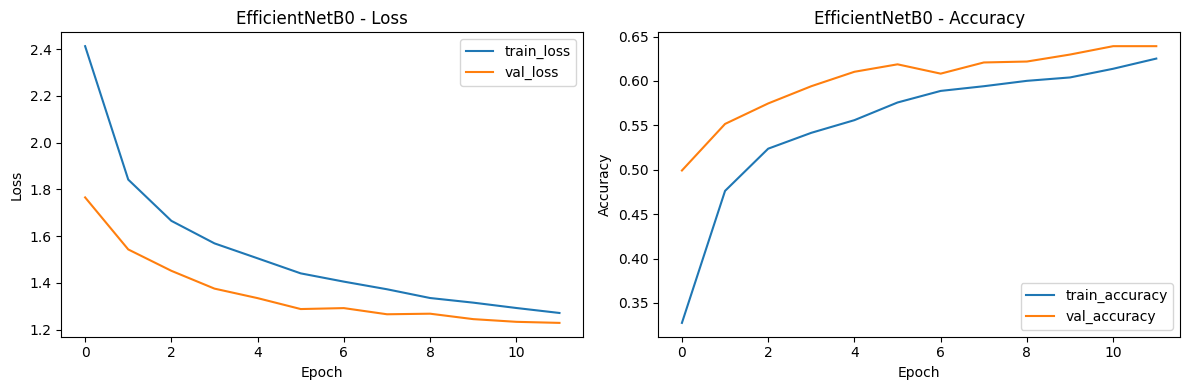

In [21]:
# Visualiser les courbes d'entraînement

history_df = pd.DataFrame(run["history"].history)
display(history_df.head())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title(f"{run['model_name']} - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title(f"{run['model_name']} - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [22]:
# Entraîner plusieurs backbones avec la même fonction

training_runs = {}

for model_name in TF_MODELS.keys():
    print(f"\n===== Training {model_name} =====")
    training_runs[model_name] = train_head_only_model(
        model_name=model_name,
        df_train=df_train,
        df_val=df_val,
        num_classes=NUM_CLASSES,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS_HEAD,
        learning_rate=LEARNING_RATE_HEAD,
        dropout_rate=DROPOUT_RATE,
    )



===== Training MobileNetV2 =====
Class weights actifs pour MobileNetV2 : False
Epoch 1/12
276/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1541 - loss: 3.1473
Epoch 1: val_accuracy improved from None to 0.31778, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/MobileNetV2_head_only_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/MobileNetV2_head_only_best.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.2277 - loss: 2.8205 - val_accuracy: 0.3178 - val_loss: 2.4350 - learning_rate: 0.0010
Epoch 2/12
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3437 - loss: 2.3221
Epoch 2: val_accuracy improved from 0.31778 to 0.37231, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/MobileNetV2_head_only_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/MobileNetV

In [23]:
# Tableau de synthèse validation

head_results = []

for model_name, run in training_runs.items():
    hist = pd.DataFrame(run["history"].history)
    best_idx = hist["val_accuracy"].idxmax()

    head_results.append({
        "model_name": model_name,
        "best_val_accuracy": hist.loc[best_idx, "val_accuracy"],
        "val_loss_at_best": hist.loc[best_idx, "val_loss"],
        "train_accuracy_at_best": hist.loc[best_idx, "accuracy"],
        "epochs_ran": len(hist),
    })

head_results_df = pd.DataFrame(head_results).sort_values(
    by="best_val_accuracy",
    ascending=False,
).reset_index(drop=True)

display(head_results_df)


,model_name,best_val_accuracy,val_loss_at_best,train_accuracy_at_best,epochs_ran
0,EfficientNetB0,0.639224,1.231701,0.622317,12
1,ResNet50,0.466702,1.936932,0.552309,12
2,MobileNetV2,0.403251,2.187156,0.489493,12


In [24]:
# Etendre la liste des modèles candidats

TF_MODELS = {
    "MobileNetV2": {
        "builder": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "input_size": (224, 224),
    },
    "EfficientNetB0": {
        "builder": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "input_size": (224, 224),
    },
    "ResNet50": {
        "builder": tf.keras.applications.ResNet50,
        "preprocess": tf.keras.applications.resnet50.preprocess_input,
        "input_size": (224, 224),
    },
    "EfficientNetV2B0": {
        "builder": tf.keras.applications.EfficientNetV2B0,
        "preprocess": tf.keras.applications.efficientnet_v2.preprocess_input,
        "input_size": (224, 224),
    },
    "EfficientNetV2B1": {
        "builder": tf.keras.applications.EfficientNetV2B1,
        "preprocess": tf.keras.applications.efficientnet_v2.preprocess_input,
        "input_size": (240, 240),
    },
    "DenseNet121": {
        "builder": tf.keras.applications.DenseNet121,
        "preprocess": tf.keras.applications.densenet.preprocess_input,
        "input_size": (224, 224),
    },
    "MobileNetV3Large": {
        "builder": tf.keras.applications.MobileNetV3Large,
        "preprocess": tf.keras.applications.mobilenet_v3.preprocess_input,
        "input_size": (224, 224),
    },
    "ConvNeXtTiny": {
        "builder": tf.keras.applications.ConvNeXtTiny,
        "preprocess": lambda x: x,
        "input_size": (224, 224),
    },
}

print(list(TF_MODELS.keys()))


['MobileNetV2', 'EfficientNetB0', 'ResNet50', 'EfficientNetV2B0', 'EfficientNetV2B1', 'DenseNet121', 'MobileNetV3Large', 'ConvNeXtTiny']


In [25]:
# Sélection des candidats à benchmarker

CANDIDATE_MODELS = [
    "EfficientNetB0",
    "EfficientNetV2B0",
    "EfficientNetV2B1",
    "DenseNet121",
    "MobileNetV3Large",
    "ConvNeXtTiny",
]

print(CANDIDATE_MODELS)


['EfficientNetB0', 'EfficientNetV2B0', 'EfficientNetV2B1', 'DenseNet121', 'MobileNetV3Large', 'ConvNeXtTiny']


In [26]:
# Petit utilitaire pour compter les paramètres

def count_params_millions(model):
    return model.count_params() / 1_000_000


In [27]:
# Benchmark propre de plusieurs candidats

import gc
import time

BENCHMARK_EPOCHS = 10
BENCHMARK_BATCH_SIZE = 32
BENCHMARK_LR = 1e-3
BENCHMARK_DROPOUT = 0.30

benchmark_runs = {}
benchmark_rows = []

for model_name in CANDIDATE_MODELS:
    print(f"\n{'=' * 15} {model_name} {'=' * 15}")

    tf.keras.backend.clear_session()
    gc.collect()

    start_time = time.time()

    run = train_head_only_model(
        model_name=model_name,
        df_train=df_train,
        df_val=df_val,
        num_classes=NUM_CLASSES,
        batch_size=BENCHMARK_BATCH_SIZE,
        epochs=BENCHMARK_EPOCHS,
        learning_rate=BENCHMARK_LR,
        dropout_rate=BENCHMARK_DROPOUT,
    )

    elapsed = time.time() - start_time
    hist = pd.DataFrame(run["history"].history)
    best_idx = hist["val_accuracy"].idxmax()

    benchmark_runs[model_name] = run
    benchmark_rows.append({
        "model_name": model_name,
        "best_val_accuracy": hist.loc[best_idx, "val_accuracy"],
        "val_loss_at_best": hist.loc[best_idx, "val_loss"],
        "train_accuracy_at_best": hist.loc[best_idx, "accuracy"],
        "epochs_ran": len(hist),
        "best_epoch": int(best_idx) + 1,
        "train_time_min": elapsed / 60,
        "input_size": TF_MODELS[model_name]["input_size"],
        "params_millions": count_params_millions(run["model"]),
    })

benchmark_results_df = pd.DataFrame(benchmark_rows).sort_values(
    by="best_val_accuracy",
    ascending=False,
).reset_index(drop=True)

display(benchmark_results_df)



=============== EfficientNetB0 ===============
Class weights actifs pour EfficientNetB0 : False
Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2394 - loss: 2.7333
Epoch 1: val_accuracy improved from None to 0.49712, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.3323 - loss: 2.4059 - val_accuracy: 0.4971 - val_loss: 1.7719 - learning_rate: 0.0010
Epoch 2/10
277/279 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4652 - loss: 1.8967
Epoch 2: val_accuracy improved from 0.49712 to 0.54536, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/

I0000 00:00:1773866212.468311  245737 service.cc:153] XLA service 0x709ee01dfd40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773866212.468362  245737 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1773866212.798393  245737 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
E0000 00:00:1773866214.766516  245737 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2244 - loss: 2.8188

E0000 00:00:1773866240.732040  245745 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.51652, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/ConvNeXtTiny_head_only_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/ConvNeXtTiny_head_only_best.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.3361 - loss: 2.3796 - val_accuracy: 0.5165 - val_loss: 1.7576 - learning_rate: 0.0010
Epoch 2/10
278/279 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4953 - loss: 1.7941
Epoch 2: val_accuracy improved from 0.51652 to 0.55165, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/ConvNeXtTiny_head_only_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/ConvNeXtTiny_head_only_best.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.5049 - loss: 1.7464 - val_accuracy: 0.5517 - val_loss: 1.5354 - learning_rate: 0.

,model_name,best_val_accuracy,val_loss_at_best,train_accuracy_at_best,epochs_ran,best_epoch,train_time_min,input_size,params_millions
0,ConvNeXtTiny,0.637651,1.241727,0.613777,10,8,3.646542,"(224, 224)",27.840122
1,EfficientNetB0,0.634504,1.237688,0.603776,10,10,1.626761,"(224, 224)",4.082877
2,EfficientNetV2B0,0.631358,1.266547,0.586021,10,10,1.484438,"(224, 224)",5.952618
3,EfficientNetV2B1,0.617200,1.261060,0.576694,10,8,1.780342,"(240, 240)",6.964430
4,MobileNetV3Large,0.610383,1.339476,0.568828,10,9,1.077288,"(224, 224)",3.021338
5,DenseNet121,0.484531,1.791795,0.446005,10,8,2.478359,"(224, 224)",7.064154


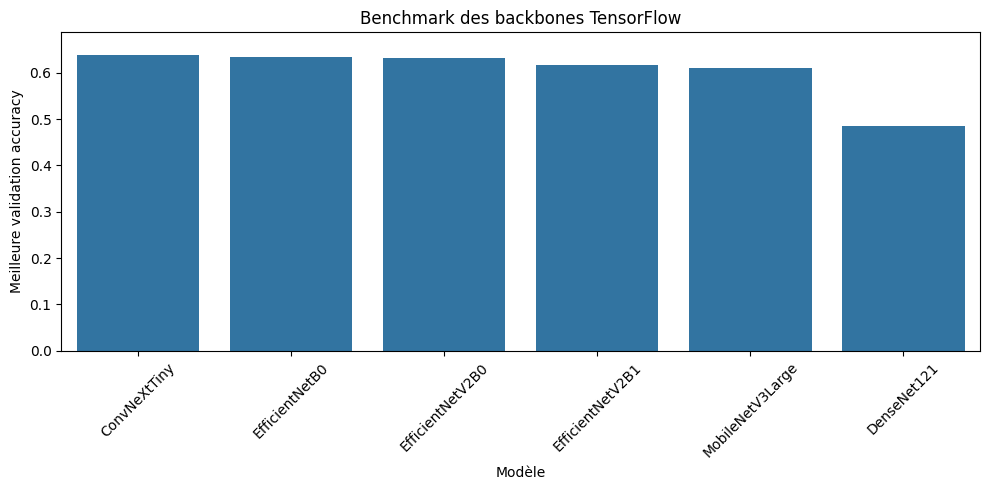

In [28]:
# Visualiser le classement des candidats

plt.figure(figsize=(10, 5))
sns.barplot(
    data=benchmark_results_df,
    x="model_name",
    y="best_val_accuracy",
)
plt.title("Benchmark des backbones TensorFlow")
plt.xlabel("Modèle")
plt.ylabel("Meilleure validation accuracy")
plt.xticks(rotation=45)
plt.ylim(0, min(1.0, benchmark_results_df["best_val_accuracy"].max() + 0.05))
plt.tight_layout()
plt.show()


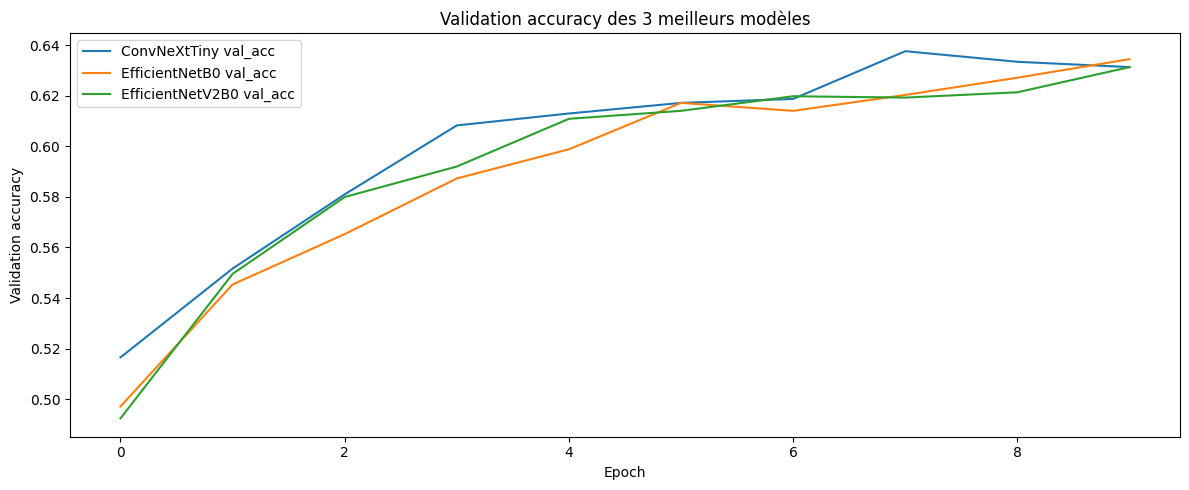

In [29]:
# Comparer les courbes des meilleurs candidats

top_k = 3
top_models = benchmark_results_df.head(top_k)["model_name"].tolist()

plt.figure(figsize=(12, 5))

for model_name in top_models:
    hist = pd.DataFrame(benchmark_runs[model_name]["history"].history)
    plt.plot(hist["val_accuracy"], label=f"{model_name} val_acc")

plt.title(f"Validation accuracy des {top_k} meilleurs modèles")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Extraire les meilleurs candidats pour la suite

TOP_MODELS_FOR_FINETUNING = benchmark_results_df.head(2)["model_name"].tolist()

print("Modèles retenus pour le fine-tuning :", TOP_MODELS_FOR_FINETUNING)
benchmark_results_df

Modèles retenus pour le fine-tuning : ['ConvNeXtTiny', 'EfficientNetB0']


,model_name,best_val_accuracy,val_loss_at_best,train_accuracy_at_best,epochs_ran,best_epoch,train_time_min,input_size,params_millions
0,ConvNeXtTiny,0.637651,1.241727,0.613777,10,8,3.646542,"(224, 224)",27.840122
1,EfficientNetB0,0.634504,1.237688,0.603776,10,10,1.626761,"(224, 224)",4.082877
2,EfficientNetV2B0,0.631358,1.266547,0.586021,10,10,1.484438,"(224, 224)",5.952618
3,EfficientNetV2B1,0.617200,1.261060,0.576694,10,8,1.780342,"(240, 240)",6.964430
4,MobileNetV3Large,0.610383,1.339476,0.568828,10,9,1.077288,"(224, 224)",3.021338
5,DenseNet121,0.484531,1.791795,0.446005,10,8,2.478359,"(224, 224)",7.064154
